In [1]:
import torch
import numpy as np
import normflows as nf
import pandas as pd

seed = 10
torch.manual_seed(seed)
np.random.seed(seed)
torch.no_grad()

import sys
import os
c_directory = os.getcwd()
sys.path.append(os.path.join(c_directory, 'FCYeast2'))

from matplotlib import pyplot as plt
import FCYeast2_simulator
import architecture

enable_cuda = True
CUDA_LAUNCH_BLOCKING=1
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/pessoa/Codes/SBI-Final/FC-inference/FCYeast2/FCYeast_simulator.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autofluo.load_state_dict(torch.load('autofluorescen

In [2]:
dils_str = ['12','23']
dils = [.12,.23]
dfs = [pd.read_csv(os.path.dirname(c_directory) +'/clean_data/complete_d={}.csv'.format(d)) for d in dils]
x = [np.log(df['FL1-A'].to_numpy()) for df in dfs]

In [3]:
Nbins = 100

h,bins=[],[]
for xi in x:
    hi,bi = np.histogram(xi,bins=Nbins)
    h.append(hi)
    bins.append(torch.tensor(bi).to(device)) #bi will be compared to simulations, keep here

In [4]:
default_means =  (10.,-1.,1. ,-2.3)
default_sigmas = ( 3.,1.5,1.5,1.0 )
target = FCYeast2_simulator.target(means=default_means,sigmas=default_sigmas)

def logprior(params):
    #z = (params-default_means)/default_sigmas
    #return -(z*z/2 + np.log(default_sigmas)).sum()
    return target.prior.log_prob(params)

In [5]:
def histogram_gpu(data,bins):
    #function needed bc torch.histogram is not working in cuda, tested against np.histogram
    bins = bins.reshape(-1,1)
    arr1 = data>bins[:-1]
    arr2 = data<=bins[1:]
    arr = torch.logical_and(arr1,arr2)
    ans = arr.sum(axis=1)
    del arr1
    del arr2
    del arr
    return ans

In [6]:
eps = float(1/Nbins) #to prevent log of 0. sums to 1, as we had one extra datapoint spread into all bins
        
def ABC_log_likelihood(param,N=2**12):
    #simulate
    params_arbitrary = FCYeast2_simulator.transform_to_arbitrary(param)
    
    simulations = target.sample(params_arbitrary,N=N,return_lparams=False)
    ll = []
    for (hi,bi,si) in zip(h,bins,simulations.T):
        db = (bi[1]-bi[0]).item()
        counts = histogram_gpu(si,bins=bi).cpu().numpy() + eps
        pi = counts/(N+1) #turn into frequencies
        pi = pi/db #turn into pdf equivalent
        ll.append( (hi*np.log(pi)).sum() )
    return ll
               
def ABC_log_post(params,lprior=logprior):
    return sum([lp.sum() for lp in ABC_log_likelihood(params)]) + lprior(params)

In [7]:
params_1k = target.prior.sample((1000,))#default_means  + default_sigmas*np.random.normal(size=(1000,7))
best_param = target.prior.loc
lp_max = ABC_log_post(best_param)

for i in range(1,10,4):
    print(i)
    for par in (1/i)*(params_1k-target.prior.loc) + best_param:
        lp_par = ABC_log_post(par)
        if lp_par>=lp_max:
            best_param = par
            lp_max=lp_par
            print(best_param.cpu().numpy(),lp_max)
            
del params_1k

1
[ 9.691429    1.5214944   0.59378296 -2.8432207  -1.5281804   1.5120171
 -3.945611  ] tensor(-575640.0625, device='cuda:0')
[14.709345   -1.3734865   0.39112866 -3.6231658  -1.2505695   0.6663041
 -2.157064  ] tensor(-507370.8750, device='cuda:0')
[14.218935   -1.3260865   2.9976573  -0.73952997 -1.6567509   0.41133207
 -2.4583273 ] tensor(-404102.8750, device='cuda:0')
[11.81861    -0.58279425  0.8212525  -2.4546933  -2.0664918   1.061936
 -3.0211225 ] tensor(-353497.6875, device='cuda:0')
[14.353535    0.01867163  3.7012224  -2.8284974  -3.116194    1.6998527
 -2.8772295 ] tensor(-342083.8125, device='cuda:0')
[11.630158   -0.8973375   0.15305388 -3.4769068  -2.326227    0.07042217
 -0.23025966] tensor(-342039.0625, device='cuda:0')
5
[11.563473   -0.5278413   0.45717013 -3.6500096  -2.4633067   0.07898407
  0.02287123] tensor(-339980.2188, device='cuda:0')
[11.701893   -0.6218302   0.48740312 -3.3635361  -2.5345423   0.02355816
 -0.40295982] tensor(-337377.1250, device='cuda:0')
[

In [8]:
param = best_param
lp = lp_max

sampled_params = [param.cpu().numpy()]
sampled_logpost = [lp.item()]

In [9]:
# # %%
S = (3.14)*torch.eye(7)*1e-4
mvn = torch.distributions.MultivariateNormal(torch.zeros(7,device=device),S.to(device))

def proposal(param):
    return param + mvn.sample()

In [12]:
for i in range(100000):
    lp = ABC_log_post(param) #resample approximation
    param_prop = proposal(param)
    lp_prop = ABC_log_post(param_prop)

    if np.log(np.random.rand(1))< (lp_prop-lp).item():
        param = param_prop
        lp = lp_prop

    sampled_params.append(param.cpu().numpy())
    sampled_logpost.append(lp.item())

    if i%100 == 99:
        print(i,param,lp, logprior(param))
        np.savetxt('FCYeast2_MCMC/ABC_results_{}.csv'.format(seed),
           np.hstack((np.stack(sampled_params), np.array(sampled_logpost).reshape(-1,1))))
np.savetxt('FCYeast2_MCMC/ABC_results_{}.csv'.format(seed),
           np.hstack((np.stack(sampled_params), np.array(sampled_logpost).reshape(-1,1))))

99 tensor([11.9637, -0.3500,  0.9492, -3.9113, -2.2938,  0.5007, -0.2052],
       device='cuda:0') tensor(-334778.0312, device='cuda:0') tensor(-13.3812, device='cuda:0')
199 tensor([11.8837, -0.2070,  1.0437, -4.0031, -2.1830,  0.3959, -0.2714],
       device='cuda:0') tensor(-337095.6875, device='cuda:0') tensor(-13.3901, device='cuda:0')
299 tensor([11.9191, -0.0469,  0.9788, -4.2276, -2.2093,  0.3996, -0.2156],
       device='cuda:0') tensor(-340656.9688, device='cuda:0') tensor(-13.9949, device='cuda:0')
399 tensor([11.9705, -0.3349,  0.8358, -4.2533, -2.2408,  0.3758, -0.3865],
       device='cuda:0') tensor(-335831.5938, device='cuda:0') tensor(-13.6402, device='cuda:0')
499 tensor([11.9572, -0.2519,  0.8423, -4.0901, -2.3669,  0.4169, -0.2580],
       device='cuda:0') tensor(-335244.8438, device='cuda:0') tensor(-13.6735, device='cuda:0')
599 tensor([11.8641, -0.4502,  0.7987, -3.8580, -2.2789,  0.5089, -0.3872],
       device='cuda:0') tensor(-336777.6250, device='cuda:0') ten

TypeError: _savetxt_dispatcher() missing 1 required positional argument: 'X'

In [47]:
#Save results for easy acess

means = np.stack(sampled_params).mean(axis=0).round(decimals=1)
dictionary = {'training_means': means, 'training_sigmas': np.ceil(np.abs(np.stack(sampled_params).std(axis=0)))}
[dictionary.update({'{}dilution'.format(dil): tensor}) for(dil,tensor) in zip(dils_str,FCYeast2_simulator.transform_to_arbitrary(torch.tensor(means).to(device)).cpu().numpy())]
torch.save(dictionary, 'ABC_estimates.pt')

In [13]:
best_param = sampled_params[np.argmax(sampled_logpost)]

In [2]:
FCYeast2_simulator.adjust_device(device)
target_after = FCYeast2_simulator.FCYeast_simulator.target()

def sanity(best_param,x=x):
    l10 = 2.302585

    fig,ax = plt.subplots(1,2,figsize=(12,4))
    h = [axi.hist(xi.cpu().numpy().reshape(-1)/l10 ,density=True,bins=45,label='Real') for (axi,xi) in zip(ax,x)]
    
    params = FCYeast2_simulator.transform_to_arbitrary(torch.tensor(best_param).to(device).float())
    #[axi.plot(*grid_plot(xi,parami,model,log10=True),label='NF Density') for (xi,parami,axi,model) in zip(x,params,ax,models)]
    [ax[i].hist(target_after.sample(params[i,:1],params[i,1:3],params[i,3:4],N=2**16,return_lparams=False).cpu().numpy()/l10 ,
            density=True,
            bins=h[i][1],alpha=.5,label='forward simulation from MAP')for i in range(2)]

    [axi.set_xlabel(r'$\log_{10}$ I') for axi in ax]

    [axi.set_title(r'Dilution {}$/h$'.format(d)) for  (axi,d) in zip(ax,[.12,.23])]
    [axi.set_xlim(.9*xi.cpu().min()/l10,xi.cpu().max()/l10) for  (axi,xi) in zip(ax,x)]

    ax[1].legend(loc=8,ncol=3,bbox_to_anchor=(.5,1.201))
    plt.tight_layout()
    #plt.savefig('FCYeast2_MCMC/sanity_check_{}seed.png'.format(seed),dpi=600)

NameError: name 'FCYeast2_simulator' is not defined

/tmp/ipykernel_18631/1477199508.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  params = FCYeast2_simulator.transform_to_arbitrary(torch.tensor(best_param).to(device).float())


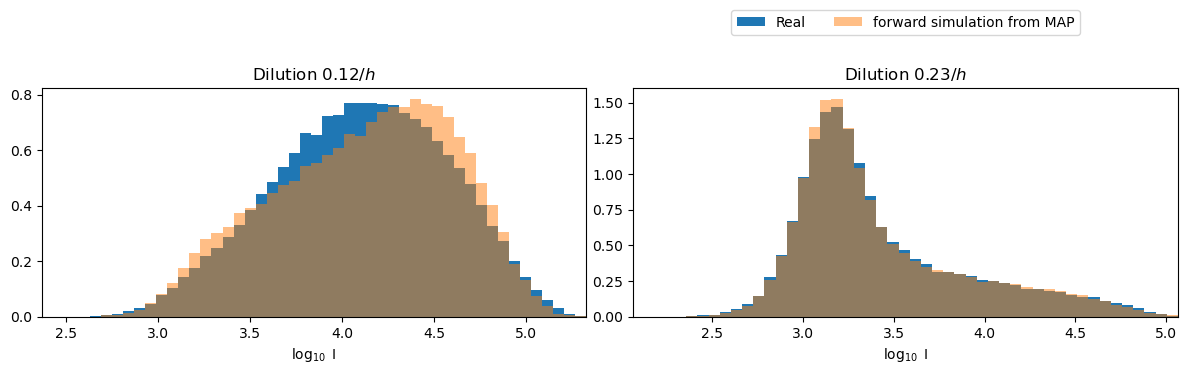

In [16]:
sanity(torch.tensor(best_param).to(device),x=[torch.tensor(xi).to(device) for xi in x])

In [2]:
torch.load('ABC_estimates.pt')

/tmp/ipykernel_108808/2054084144.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load('ABC_estimates.pt')


{'training_means': array([13. , -0.2,  2.3, -2.9, -2.4,  1.3, -1. ], dtype=float32),
 'training_sigmas': array([1., 1., 1., 1., 1., 1., 1.], dtype=float32),
 '12dilution': array([15.120264, -0.2     ,  2.3     , -2.9     ], dtype=float32),
 '23dilution': array([14.469676, -2.4     ,  1.3     , -1.      ], dtype=float32)}